# BR-101 EDA Notebook 4: Weekly Local RNN Forecasting

This notebook reuses notebook 3's dense weekly panel, assigns train-derived `RGI` activity groups for analysis, and trains local recurrent models per `RGI` instead of pooled group models.

Models in scope:

- per-`RGI` `GRU`
- per-`RGI` `LSTM`

Operational forecasting setup:

- train: `2017-W01` through `2023-W52`
- validation: `2024-W01` through `2024-W52`
- test: `2025-W01` through `2025-W52`
- lookback: `52` weeks
- latency gap: `4` weeks
- forecast horizon: `8` weeks
- forecast-origin stride: `4` weeks

Artifacts are written under `data/silver/notebook4_local_rnn_accident_count` and `data/gold/notebook4_local_rnn_accident_count`.


In [1]:
from pathlib import Path
from time import perf_counter
import importlib

import pandas as pd
import seaborn as sns
from IPython.display import display

import sys
sys.path.insert(0, str(Path().resolve().parent))

from src.etl.silver import notebook4_pipeline as nb4
nb4 = importlib.reload(nb4)

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')

CONFIG = nb4.Notebook4Config.from_project_root()
CONFIG.ensure_output_dirs()

print(f'Notebook 3 silver dir: {CONFIG.notebook3_silver_dir}')
print(f'Notebook 3 gold dir: {CONFIG.notebook3_gold_dir}')
print(f'Notebook 4 silver dir: {CONFIG.silver_output_dir}')
print(f'Notebook 4 gold dir: {CONFIG.gold_output_dir}')
print(nb4.tensorflow_status_message())


I0000 00:00:1775139193.539346  363954 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1775139193.539847  363954 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1775139193.569983  363954 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI AVX_VNNI_INT8 AVX_NE_CONVERT FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1775139194.527445  363954 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENAB

Notebook 3 silver dir: /home/arthur/Documents/projects/radar-prf-101/data/silver/notebook3_accident_count
Notebook 3 gold dir: /home/arthur/Documents/projects/radar-prf-101/data/gold/notebook3_accident_count
Notebook 4 silver dir: /home/arthur/Documents/projects/radar-prf-101/data/silver/notebook4_local_rnn_accident_count
Notebook 4 gold dir: /home/arthur/Documents/projects/radar-prf-101/data/gold/notebook4_local_rnn_accident_count
TensorFlow runtime available: 2.21.0


In [2]:
inputs = nb4.load_notebook4_inputs(CONFIG)
weekly_rgi_panel = inputs['weekly_rgi_panel']
notebook3_benchmark_metrics = inputs['notebook3_benchmark_metrics']

weekly_rgi_panel.to_parquet(CONFIG.silver_output_dir / 'weekly_rgi_panel_reused.parquet', index=False)

print(f'Notebook 3 weekly panel rows: {len(weekly_rgi_panel):,}')
print(f'Retained RGIs: {weekly_rgi_panel["rgi_id"].nunique():,}')
display(weekly_rgi_panel.head())
display(weekly_rgi_panel['split'].value_counts(dropna=False).to_frame('rows'))

if not notebook3_benchmark_metrics.empty:
    display(notebook3_benchmark_metrics.sort_values(['split', 'rmse']).head(10))


Notebook 3 weekly panel rows: 23,919
Retained RGIs: 51


,rgi_id,rgi_name,uf,rgint_id,rgint_name,br101_length_m_in_rgi,br101_length_km_in_rgi,week_start,week_end,iso_year,iso_week,year_week,week_index,accident_count,prev_week_non_work_day_share,prev_week_longest_non_work_streak,curr_week_non_work_day_share,curr_week_longest_non_work_streak,next_week_non_work_day_share,next_week_longest_non_work_streak,split,is_train,is_validation,is_test
0,240001,Natal,RN,2401,Natal,144592.537787,144.592538,2017-01-02,2017-01-08,2017,1,2017-W01,0,7,0.000000,0.0,0.285714,2.0,0.285714,2.0,train,True,False,False
1,240001,Natal,RN,2401,Natal,144592.537787,144.592538,2017-01-09,2017-01-15,2017,2,2017-W02,1,4,0.285714,2.0,0.285714,2.0,0.285714,2.0,train,True,False,False
2,240001,Natal,RN,2401,Natal,144592.537787,144.592538,2017-01-16,2017-01-22,2017,3,2017-W03,2,6,0.285714,2.0,0.285714,2.0,0.285714,2.0,train,True,False,False
3,240001,Natal,RN,2401,Natal,144592.537787,144.592538,2017-01-23,2017-01-29,2017,4,2017-W04,3,9,0.285714,2.0,0.285714,2.0,0.285714,2.0,train,True,False,False
4,240001,Natal,RN,2401,Natal,144592.537787,144.592538,2017-01-30,2017-02-05,2017,5,2017-W05,4,9,0.285714,2.0,0.285714,2.0,0.285714,2.0,train,True,False,False


,rows
split,
train,18615
validation,2652
test,2652


,model,split,rmse,n_predictions,n_rgis_with_predictions,macro_rgi_rmse,n_target_rows,forecast_row_coverage
0,rnn_global,test,2.604477,2652.0,51.0,1.890966,2652,1.0
1,moving_average_4w,test,2.765979,2652.0,51.0,1.979757,2652,1.0
2,seasonal_naive,test,3.330070,2652.0,51.0,2.441680,2652,1.0
3,rnn_global,validation,2.457936,2652.0,51.0,1.810434,2652,1.0
4,moving_average_4w,validation,2.536758,2652.0,51.0,1.868503,2652,1.0
5,seasonal_naive,validation,3.171149,2652.0,51.0,2.348807,2652,1.0


In [3]:
rgi_activity_summary = nb4.build_rgi_activity_summary(weekly_rgi_panel)
rgi_activity_summary = nb4.assign_activity_groups(rgi_activity_summary, CONFIG)
weekly_rgi_panel_with_groups = nb4.attach_activity_groups(weekly_rgi_panel, rgi_activity_summary)

rgi_activity_summary.to_parquet(CONFIG.silver_output_dir / 'rgi_activity_summary.parquet', index=False)
rgi_activity_summary.to_parquet(CONFIG.silver_output_dir / 'rgi_group_assignments.parquet', index=False)
weekly_rgi_panel_with_groups.to_parquet(CONFIG.silver_output_dir / 'weekly_rgi_panel_with_groups.parquet', index=False)

display(rgi_activity_summary.head(20))
display(rgi_activity_summary['group_name'].value_counts().rename_axis('group_name').to_frame('n_rgis'))


,rgi_id,rgi_name,uf,train_total_accidents,train_mean_weekly_accidents,train_median_weekly_accidents,train_active_week_share,train_zero_week_share,train_mean_positive_weekly_accidents,br101_length_km_in_rgi,activity_rank,group_name,group_order
0,270005,União dos Palmares,AL,0,0.000000,0.0,0.000000,1.000000,0.000000,0.361508,1,low_activity,0
1,350002,Santos,SP,0,0.000000,0.0,0.000000,1.000000,0.000000,258.886245,2,low_activity,0
2,350005,Registro,SP,0,0.000000,0.0,0.000000,1.000000,0.000000,185.757526,3,low_activity,0
3,350051,Caraguatatuba - Ubatuba - São Sebastião,SP,0,0.000000,0.0,0.000000,1.000000,0.000000,236.082843,4,low_activity,0
4,430001,Porto Alegre,RS,0,0.000000,0.0,0.000000,1.000000,0.000000,186.498833,5,low_activity,0
5,430003,Tramandaí - Osório,RS,0,0.000000,0.0,0.000000,1.000000,0.000000,106.866819,6,low_activity,0
6,430009,Pelotas,RS,0,0.000000,0.0,0.000000,1.000000,0.000000,147.617221,7,low_activity,0
7,430008,Torres,RS,1,0.002740,0.0,0.002740,0.997260,1.000000,42.585238,8,low_activity,0
8,410002,Paranaguá,PR,3,0.008219,0.0,0.008219,0.991781,1.000000,254.703435,9,low_activity,0
9,290006,Nazaré - Maragogipe,BA,4,0.010959,0.0,0.010959,0.989041,1.000000,1.254928,10,low_activity,0


,n_rgis
group_name,
mid_activity,31
low_activity,10
high_activity,10


,diagnostic_group,group_name,diagnostic_name,split,value
0,membership,low_activity,n_rgis,overall,10.000000
1,train_activity,low_activity,mean_weekly_accidents_mean,train,0.002192
2,train_activity,low_activity,zero_week_share_mean,train,0.997808
3,train_panel,low_activity,rows,train,3650.000000
4,membership,mid_activity,n_rgis,overall,31.000000
5,train_activity,mid_activity,mean_weekly_accidents_mean,train,2.012726
6,train_activity,mid_activity,zero_week_share_mean,train,0.261511
7,train_panel,mid_activity,rows,train,11315.000000
8,membership,high_activity,n_rgis,overall,10.000000
9,train_activity,high_activity,mean_weekly_accidents_mean,train,14.802466


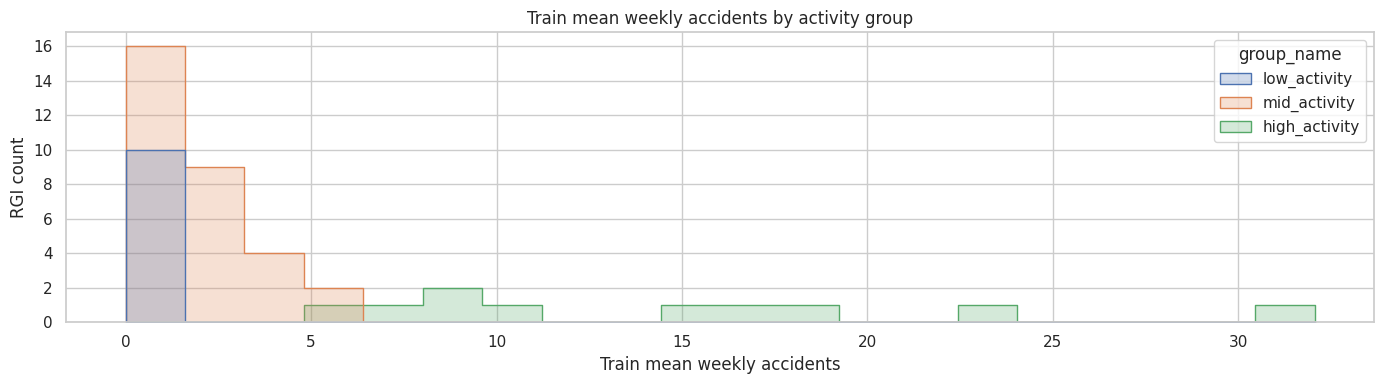

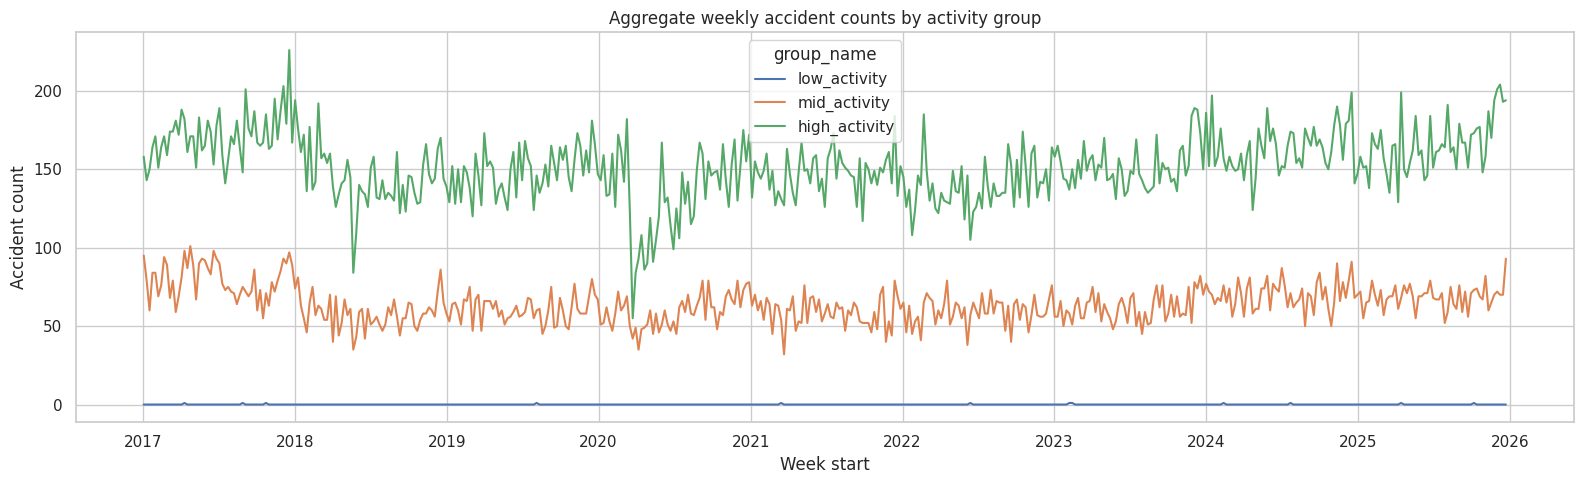

In [4]:
group_diagnostics = nb4.build_group_diagnostics(weekly_rgi_panel_with_groups, rgi_activity_summary)
group_diagnostics.to_parquet(CONFIG.silver_output_dir / 'group_diagnostics.parquet', index=False)

display(group_diagnostics)
nb4.plot_group_diagnostics(weekly_rgi_panel_with_groups, rgi_activity_summary)


In [5]:
local_datasets = nb4.prepare_local_rnn_datasets(weekly_rgi_panel_with_groups, CONFIG)
sequence_manifest = nb4.build_sequence_manifest(local_datasets)
sequence_manifest.to_parquet(CONFIG.silver_output_dir / 'sequence_manifest.parquet', index=False)

display(sequence_manifest.head(20))
print('RGIs with train samples:', int(sequence_manifest.loc[sequence_manifest['split'].eq('train'), 'n_samples'].gt(0).sum()))
print('RGIs with validation samples:', int(sequence_manifest.loc[sequence_manifest['split'].eq('validation'), 'n_samples'].gt(0).sum()))
print('RGIs with test samples:', int(sequence_manifest.loc[sequence_manifest['split'].eq('test'), 'n_samples'].gt(0).sum()))


,rgi_id,rgi_name,uf,group_name,split,n_samples,min_week_start,max_week_start
0,240001,Natal,RN,high_activity,test,12,2024-12-30,2025-11-03
1,240001,Natal,RN,high_activity,train,303,2018-01-22,2023-11-06
2,240001,Natal,RN,high_activity,validation,12,2024-01-01,2024-11-04
3,250001,João Pessoa,PB,high_activity,test,12,2024-12-30,2025-11-03
4,250001,João Pessoa,PB,high_activity,train,303,2018-01-22,2023-11-06
5,250001,João Pessoa,PB,high_activity,validation,12,2024-01-01,2024-11-04
6,260001,Recife,PE,high_activity,test,12,2024-12-30,2025-11-03
7,260001,Recife,PE,high_activity,train,303,2018-01-22,2023-11-06
8,260001,Recife,PE,high_activity,validation,12,2024-01-01,2024-11-04
9,320001,Vitória,ES,high_activity,test,12,2024-12-30,2025-11-03


RGIs with train samples: 51
RGIs with validation samples: 51
RGIs with test samples: 51


In [6]:
nb4.require_tensorflow()

training_runs = []
training_timer = perf_counter()
for rgi_id, dataset in local_datasets.items():
    for architecture in ['gru', 'lstm']:
        print(f'Training {architecture.upper()} for RGI {rgi_id}...')
        training_runs.append(
            nb4.train_local_model(
                dataset['train'],
                dataset['validation'],
                CONFIG,
                architecture=architecture,
            )
        )

training_histories = nb4.flatten_training_histories(training_runs)
model_run_summary = nb4.build_model_run_summary(training_runs)
training_histories.to_parquet(CONFIG.gold_output_dir / 'training_histories.parquet', index=False)
model_run_summary.to_parquet(CONFIG.gold_output_dir / 'model_run_summary.parquet', index=False)

elapsed = perf_counter() - training_timer
print(f'Total training runtime: {elapsed:,.1f} seconds')
display(model_run_summary.head(20))
display(training_histories.tail(20))


Training GRU for RGI 240001...


E0000 00:00:1775139210.366175  363954 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


240001 GRU training: 0epoch [00:00, ?epoch/s]

Training LSTM for RGI 240001...


240001 LSTM training: 0epoch [00:00, ?epoch/s]

...

Training LSTM for RGI 430009...


430009 LSTM training: 0epoch [00:00, ?epoch/s]

Total training runtime: 532.1 seconds


,rgi_id,group_name,architecture,best_epoch,best_val_loss,runtime_seconds,n_train_samples,n_validation_samples
0,240001,high_activity,gru,17,0.122491,4.803587,303,12
1,240001,high_activity,lstm,17,0.123054,3.702141,303,12
2,250001,high_activity,gru,23,0.188763,5.524630,303,12
3,250001,high_activity,lstm,23,0.188724,4.555295,303,12
4,260001,high_activity,gru,17,0.099535,4.376958,303,12
5,260001,high_activity,lstm,17,0.099690,3.834032,303,12
6,320001,high_activity,gru,11,0.056312,3.451593,303,12
7,320001,high_activity,lstm,11,0.056230,3.081757,303,12
8,320004,high_activity,gru,15,0.117802,3.879451,303,12
9,320004,high_activity,lstm,15,0.117772,3.542172,303,12


,rgi_id,group_name,architecture,epoch,loss,rmse,val_loss,val_rmse
2907,420004,mid_activity,lstm,4,0.587809,0.766687,0.635082,0.796920
2908,420004,mid_activity,lstm,5,0.465813,0.682505,0.457825,0.676628
2909,420004,mid_activity,lstm,6,0.332327,0.576478,0.348084,0.589987
2910,420004,mid_activity,lstm,7,0.270693,0.520282,0.280717,0.529828
2911,420004,mid_activity,lstm,8,0.228974,0.478512,0.242878,0.492826
2912,420004,mid_activity,lstm,9,0.204982,0.452749,0.218080,0.466990
2913,420004,mid_activity,lstm,10,0.189144,0.434907,0.203102,0.450668
2914,420004,mid_activity,lstm,11,0.180091,0.424371,0.193342,0.439707
2915,420004,mid_activity,lstm,12,0.174626,0.417883,0.186689,0.432075
2916,420004,mid_activity,lstm,13,0.171419,0.414028,0.182821,0.427576


In [7]:
validation_frames = []
test_frames = []
for run in training_runs:
    dataset = local_datasets[run['rgi_id']]
    validation_frames.append(
        nb4.generate_rnn_forecasts(
            run['model'],
            dataset['validation'],
            architecture=run['architecture'],
        )
    )
    test_frames.append(
        nb4.generate_rnn_forecasts(
            run['model'],
            dataset['test'],
            architecture=run['architecture'],
        )
    )

validation_forecasts = nb4.combine_forecasts(*validation_frames)
test_forecasts = nb4.combine_forecasts(*test_frames)
combined_forecasts = nb4.combine_forecasts(validation_forecasts, test_forecasts)

for architecture in ['gru', 'lstm']:
    validation_forecasts.loc[validation_forecasts['architecture'].eq(architecture)].to_parquet(
        CONFIG.gold_output_dir / f'{architecture}_validation_forecasts.parquet',
        index=False,
    )
    test_forecasts.loc[test_forecasts['architecture'].eq(architecture)].to_parquet(
        CONFIG.gold_output_dir / f'{architecture}_test_forecasts.parquet',
        index=False,
    )

display(validation_forecasts.head())
display(test_forecasts.head())


,model,architecture,group_name,split,rgi_id,rgi_name,uf,week_start,week_end,year_week,forecast_batch_start,cutoff_week_start,horizon_step,prediction,actual,is_available,metadata
0,local_gru,gru,high_activity,validation,240001,Natal,RN,2024-01-01,2024-01-07,2024-W01,2024-01-01,2023-12-04,1,10,10,True,target_scale=10.9123; rounded_to_int=1
1,local_gru,gru,high_activity,validation,240001,Natal,RN,2024-01-08,2024-01-14,2024-W02,2024-01-01,2023-12-04,2,10,12,True,target_scale=10.9123; rounded_to_int=1
2,local_gru,gru,high_activity,validation,240001,Natal,RN,2024-01-15,2024-01-21,2024-W03,2024-01-01,2023-12-04,3,10,24,True,target_scale=10.9123; rounded_to_int=1
3,local_gru,gru,high_activity,validation,240001,Natal,RN,2024-01-22,2024-01-28,2024-W04,2024-01-01,2023-12-04,4,10,16,True,target_scale=10.9123; rounded_to_int=1
4,local_gru,gru,high_activity,validation,240001,Natal,RN,2024-01-29,2024-02-04,2024-W05,2024-01-01,2023-12-04,5,10,8,True,target_scale=10.9123; rounded_to_int=1


,model,architecture,group_name,split,rgi_id,rgi_name,uf,week_start,week_end,year_week,forecast_batch_start,cutoff_week_start,horizon_step,prediction,actual,is_available,metadata
0,local_gru,gru,high_activity,test,240001,Natal,RN,2024-12-30,2025-01-05,2025-W01,2024-12-30,2024-12-02,1,10,14,True,target_scale=10.9123; rounded_to_int=1
1,local_gru,gru,high_activity,test,240001,Natal,RN,2025-01-06,2025-01-12,2025-W02,2024-12-30,2024-12-02,2,10,10,True,target_scale=10.9123; rounded_to_int=1
2,local_gru,gru,high_activity,test,240001,Natal,RN,2025-01-13,2025-01-19,2025-W03,2024-12-30,2024-12-02,3,10,16,True,target_scale=10.9123; rounded_to_int=1
3,local_gru,gru,high_activity,test,240001,Natal,RN,2025-01-20,2025-01-26,2025-W04,2024-12-30,2024-12-02,4,10,6,True,target_scale=10.9123; rounded_to_int=1
4,local_gru,gru,high_activity,test,240001,Natal,RN,2025-01-27,2025-02-02,2025-W05,2024-12-30,2024-12-02,5,10,7,True,target_scale=10.9123; rounded_to_int=1


In [8]:
benchmark_metrics, group_level_metrics, rgi_level_metrics, horizon_level_metrics = nb4.evaluate_forecasts(
    weekly_rgi_panel_with_groups,
    combined_forecasts,
    CONFIG,
)

benchmark_metrics.to_parquet(CONFIG.gold_output_dir / 'benchmark_metrics.parquet', index=False)
benchmark_metrics.to_csv(CONFIG.gold_output_dir / 'benchmark_metrics.csv', index=False)
group_level_metrics.to_parquet(CONFIG.gold_output_dir / 'group_level_metrics.parquet', index=False)
rgi_level_metrics.to_parquet(CONFIG.gold_output_dir / 'rgi_level_metrics.parquet', index=False)
horizon_level_metrics.to_parquet(CONFIG.gold_output_dir / 'horizon_level_metrics.parquet', index=False)

display(benchmark_metrics.sort_values(['split', 'rmse']))
display(group_level_metrics.sort_values(['split', 'group_name', 'rmse']))
display(horizon_level_metrics.sort_values(['split', 'group_name', 'horizon_step']))
display(rgi_level_metrics.sort_values(['split', 'architecture', 'rmse'], ascending=[True, True, False]).head(20))

if not notebook3_benchmark_metrics.empty:
    notebook3_rnn = notebook3_benchmark_metrics.loc[
        notebook3_benchmark_metrics['model'].astype(str).eq('rnn_global')
    ].copy()
    if not notebook3_rnn.empty:
        notebook3_rnn = notebook3_rnn.assign(comparison_source='notebook3_global_rnn')[
            ['comparison_source', 'model', 'split', 'rmse', 'forecast_row_coverage', 'n_predictions']
        ]
        notebook4_summary = benchmark_metrics.assign(comparison_source='notebook4_local_rnn')[
            ['comparison_source', 'model', 'split', 'rmse', 'forecast_row_coverage', 'n_predictions']
        ]
        display(pd.concat([notebook3_rnn, notebook4_summary], ignore_index=True).sort_values(['split', 'rmse']))


,model,architecture,split,rmse,r2,n_predictions,macro_rmse,n_rgis_with_predictions,n_groups_with_predictions,expected_rows,forecast_row_coverage
0,local_lstm,lstm,test,2.818009,0.857666,4896.0,1.958157,51,3,4896,1.0
1,local_gru,gru,test,2.822934,0.857168,4896.0,1.962644,51,3,4896,1.0
2,local_gru,gru,validation,2.624981,0.875985,4896.0,1.860482,51,3,4896,1.0
3,local_lstm,lstm,validation,2.632401,0.875283,4896.0,1.864102,51,3,4896,1.0


,model,architecture,group_name,split,rmse,r2,n_predictions,macro_rmse,n_group_rgis,n_rgis_with_predictions,expected_rows,forecast_row_coverage
0,local_gru,gru,high_activity,test,5.614713,0.631262,960.0,5.271151,10,10,960,1.0
1,local_lstm,lstm,high_activity,test,5.625093,0.629897,960.0,5.282645,10,10,960,1.0
2,local_gru,gru,low_activity,test,0.064550,-0.004184,960.0,0.020412,10,10,960,1.0
3,local_lstm,lstm,low_activity,test,0.064550,-0.004184,960.0,0.020412,10,10,960,1.0
4,local_lstm,lstm,mid_activity,test,1.690024,0.557831,2976.0,1.510820,31,31,2976,1.0
5,local_gru,gru,mid_activity,test,1.714502,0.544930,2976.0,1.521911,31,31,2976,1.0
6,local_gru,gru,high_activity,validation,5.173853,0.702991,960.0,4.871796,10,10,960,1.0
7,local_lstm,lstm,high_activity,validation,5.200861,0.699882,960.0,4.894110,10,10,960,1.0
8,local_gru,gru,low_activity,validation,0.064550,-0.004184,960.0,0.028868,10,10,960,1.0
9,local_lstm,lstm,low_activity,validation,0.064550,-0.004184,960.0,0.028868,10,10,960,1.0


,model,architecture,group_name,split,horizon_step,rmse,r2,n_predictions
0,local_gru,gru,high_activity,test,1,4.590752,0.718741,120.0
1,local_lstm,lstm,high_activity,test,1,4.598913,0.717740,120.0
2,local_gru,gru,high_activity,test,2,5.690636,0.632980,120.0
3,local_lstm,lstm,high_activity,test,2,5.732946,0.627502,120.0
4,local_gru,gru,high_activity,test,3,5.403702,0.613620,120.0
...,...,...,...,...,...,...,...,...
91,local_lstm,lstm,mid_activity,validation,6,1.692012,0.481686,372.0
92,local_gru,gru,mid_activity,validation,7,1.754411,0.569244,372.0
93,local_lstm,lstm,mid_activity,validation,7,1.796053,0.548553,372.0
94,local_gru,gru,mid_activity,validation,8,1.715677,0.555117,372.0


,model,architecture,group_name,split,rgi_id,rgi_name,uf,rmse,r2,n_predictions,expected_rows,forecast_row_coverage
50,local_gru,gru,high_activity,test,330001,Rio de Janeiro,RJ,9.250563,-1.071144,96.0,96,1.0
49,local_gru,gru,high_activity,test,420001,Florianópolis,SC,7.045241,-0.109526,96.0,96,1.0
48,local_gru,gru,high_activity,test,420020,Itajaí,SC,6.667708,-0.785471,96.0,96,1.0
47,local_gru,gru,high_activity,test,320001,Vitória,ES,6.133922,-0.608222,96.0,96,1.0
46,local_gru,gru,high_activity,test,260001,Recife,PE,5.703617,-0.063028,96.0,96,1.0
45,local_gru,gru,mid_activity,test,330002,Angra dos Reis,RJ,4.540329,-0.989966,96.0,96,1.0
44,local_gru,gru,high_activity,test,320004,Linhares,ES,4.081207,-0.211517,96.0,96,1.0
43,local_gru,gru,high_activity,test,420016,Joinville,SC,3.899786,-0.039886,96.0,96,1.0
42,local_gru,gru,high_activity,test,240001,Natal,RN,3.803781,-0.421714,96.0,96,1.0
41,local_gru,gru,high_activity,test,250001,João Pessoa,PB,3.470110,-0.642653,96.0,96,1.0


,comparison_source,model,split,rmse,forecast_row_coverage,n_predictions
0,notebook3_global_rnn,rnn_global,test,2.604477,1.0,2652.0
2,notebook4_local_rnn,local_lstm,test,2.818009,1.0,4896.0
3,notebook4_local_rnn,local_gru,test,2.822934,1.0,4896.0
1,notebook3_global_rnn,rnn_global,validation,2.457936,1.0,2652.0
4,notebook4_local_rnn,local_gru,validation,2.624981,1.0,4896.0
5,notebook4_local_rnn,local_lstm,validation,2.632401,1.0,4896.0


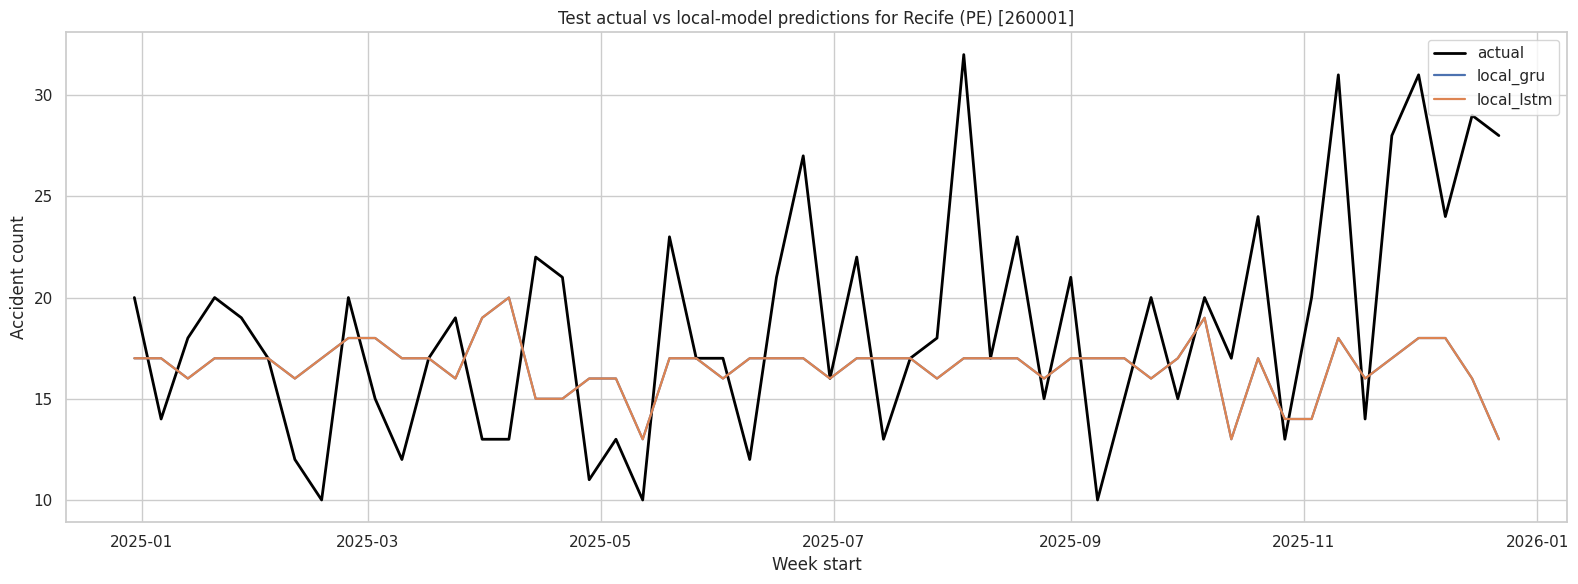

,architecture,horizon_step,rmse,n_predictions
0,gru,1,4.242641,12.0
1,gru,2,5.802298,12.0
2,gru,3,3.851407,12.0
3,gru,4,6.664583,12.0
4,gru,5,5.446712,12.0
5,gru,6,5.454356,12.0
6,gru,7,5.431390,12.0
7,gru,8,7.772816,12.0
8,lstm,1,4.242641,12.0
9,lstm,2,5.802298,12.0


In [14]:
example_rgi = str(rgi_activity_summary.loc[rgi_activity_summary['group_name'].eq('high_activity'), 'rgi_id'].iloc[6])
rgi_test_horizon_rmse = nb4.plot_test_predictions_for_rgi(
    weekly_rgi_panel_with_groups,
    test_forecasts,
    rgi_id=example_rgi,
    split='test',
)
display(rgi_test_horizon_rmse)


## Closing Notes

After execution, summarize here:

- whether local per-`RGI` models improved over notebook 3's global RNN
- which architecture won overall on validation and test
- which architecture won within each activity group after aggregating local-model forecasts
- whether the low-activity group remains intrinsically difficult to forecast
- what should change next if another modeling notebook is needed
